In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = pd.read_csv("../data/cleaned_churn_data.csv")

In [14]:
data.head()

,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


In [15]:
data.columns.tolist()

['City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'CLTV']

In [16]:
numerical_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [17]:
data[numerical_columns].dtypes

Tenure Months        int64
Monthly Charges    float64
Total Charges          str
CLTV                 int64
dtype: object

In [19]:
summary = data[numerical_columns].agg(
    ["mean", "median", "min", "max"]
)

summary

TypeError: Cannot perform reduction 'mean' with string dtype

In [20]:
data[numerical_columns].dtypes



Tenure Months        int64
Monthly Charges    float64
Total Charges          str
CLTV                 int64
dtype: object

In [22]:
data["Tenure Months"] = pd.to_numeric(data["Tenure Months"], errors="coerce")
data["Monthly Charges"] = pd.to_numeric(data["Monthly Charges"], errors="coerce")
data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce")
data["CLTV"] = pd.to_numeric(data["CLTV"], errors="coerce")

In [24]:
data[numerical_columns].dtypes

Tenure Months        int64
Monthly Charges    float64
Total Charges      float64
CLTV                 int64
dtype: object

In [25]:
summary = data[numerical_columns].agg(
    ["mean", "median", "min", "max"]
)

summary

,Tenure Months,Monthly Charges,Total Charges,CLTV
mean,32.371149,64.761692,2283.300441,4400.295755
median,29.000000,70.350000,1397.475000,4527.000000
min,0.000000,18.250000,18.800000,2003.000000
max,72.000000,118.750000,8684.800000,6500.000000


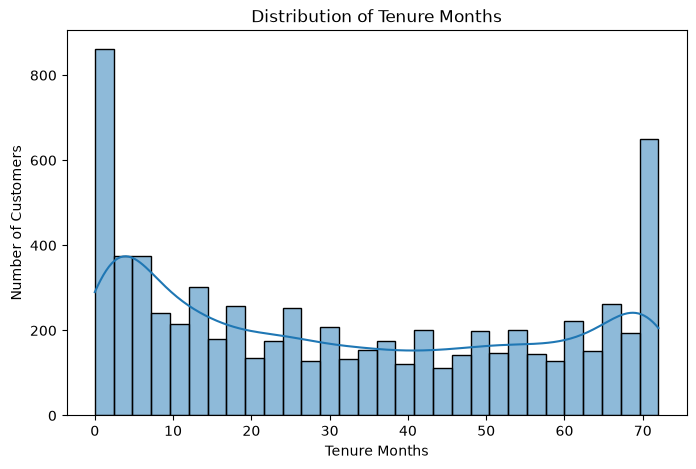

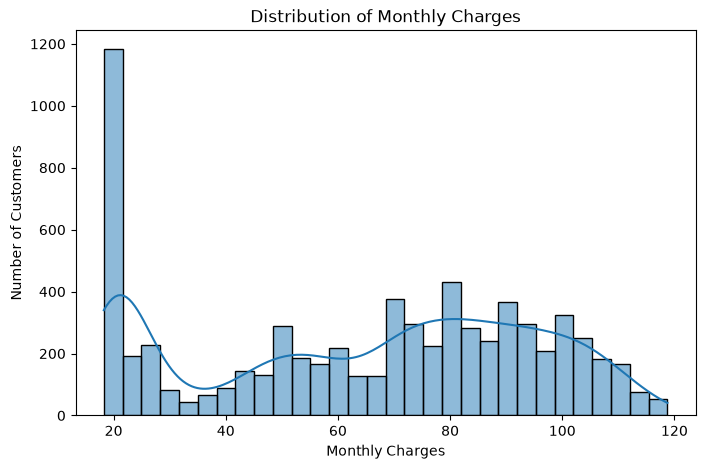

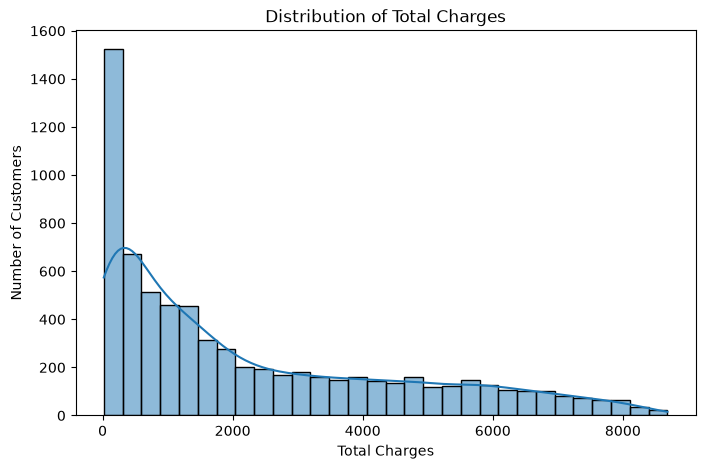

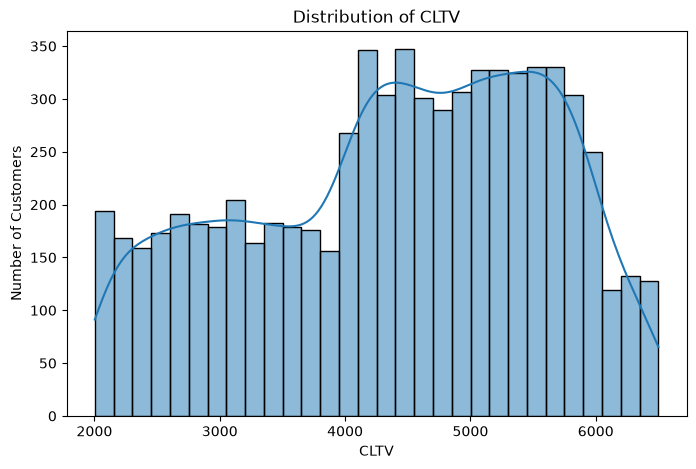

In [26]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(data[column], bins=30, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")

    plt.show()

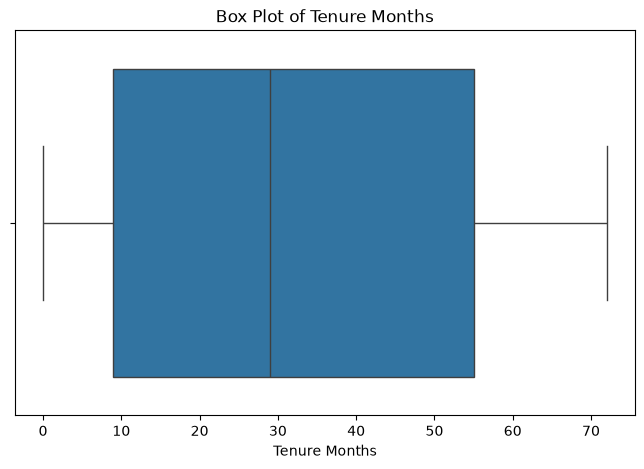

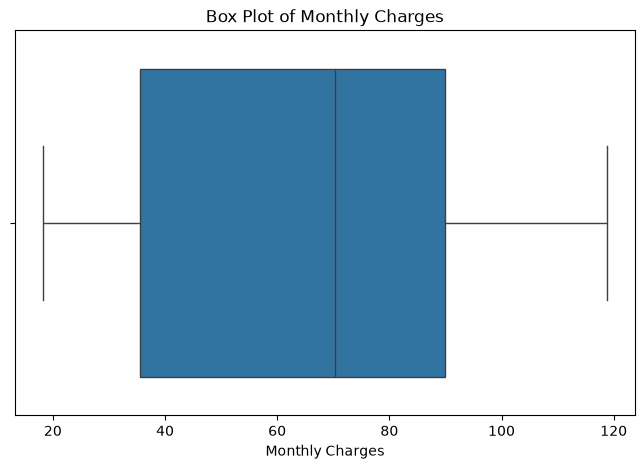

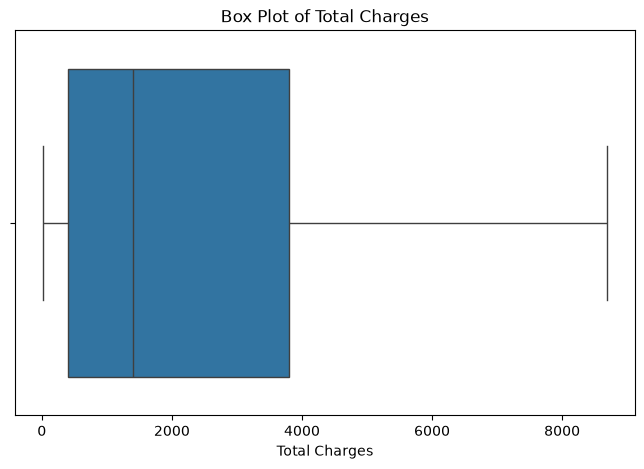

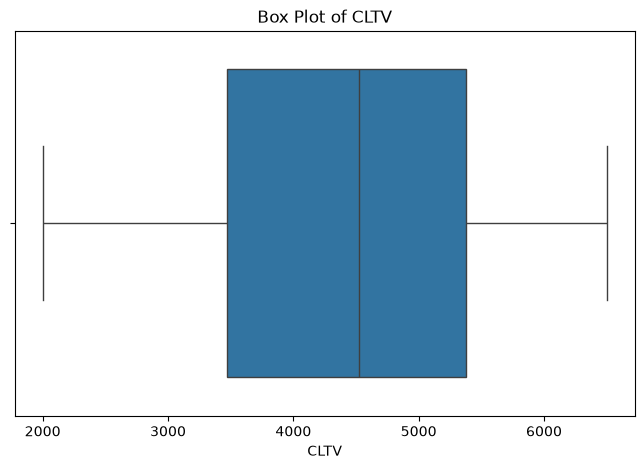

In [27]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.boxplot(x=data[column])

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)

    plt.show()

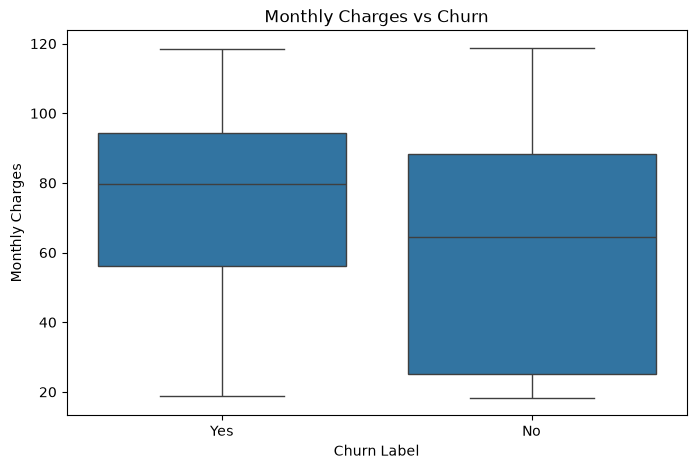

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Monthly Charges",
    data=data
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")

plt.show()

In [29]:
data.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


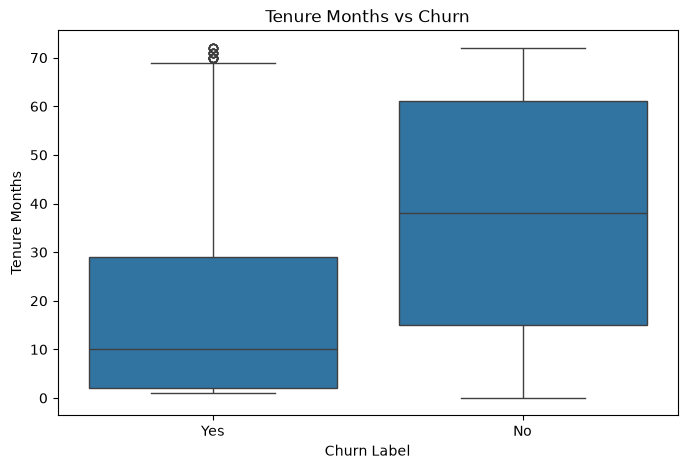

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Tenure Months",
    data=data
)

plt.title("Tenure Months vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Tenure Months")

plt.show()

In [31]:
data.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


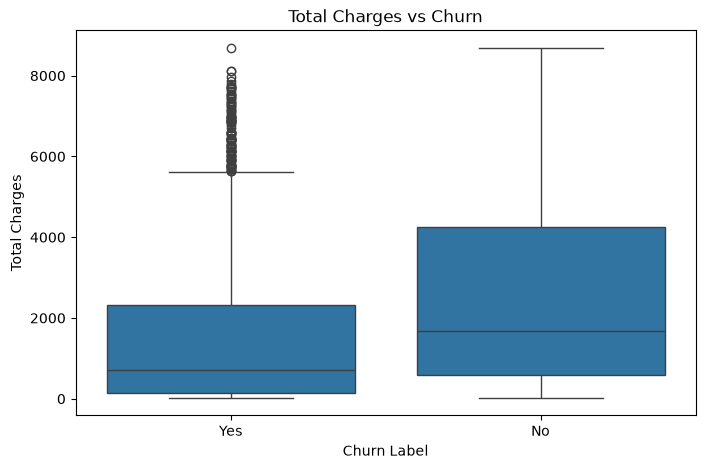

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=data
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")

plt.show()

In [33]:
data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


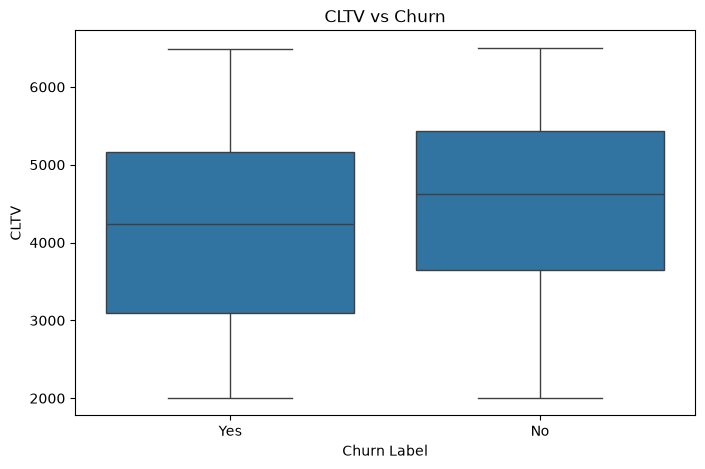

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="CLTV",
    data=data
)

plt.title("CLTV vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("CLTV")

plt.show()


In [35]:
data.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,4490.921337,4620.0,2003,6500
Yes,4149.414660,4238.0,2003,6484


In [36]:
data.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


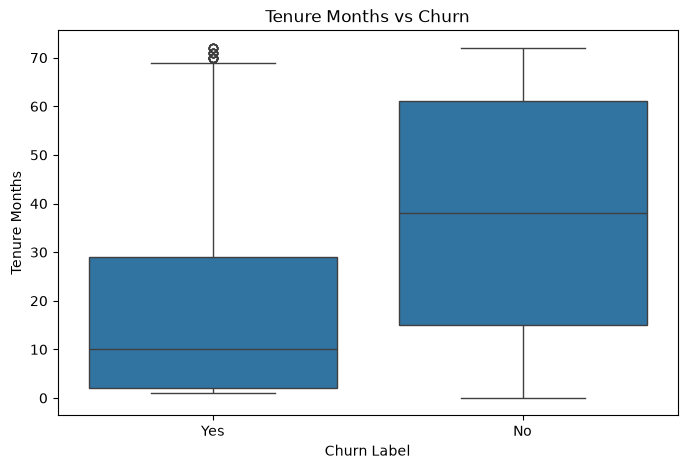

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Tenure Months",
    data=data
)

plt.title("Tenure Months vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Tenure Months")

plt.show()

In [38]:
data.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


In [39]:
data.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


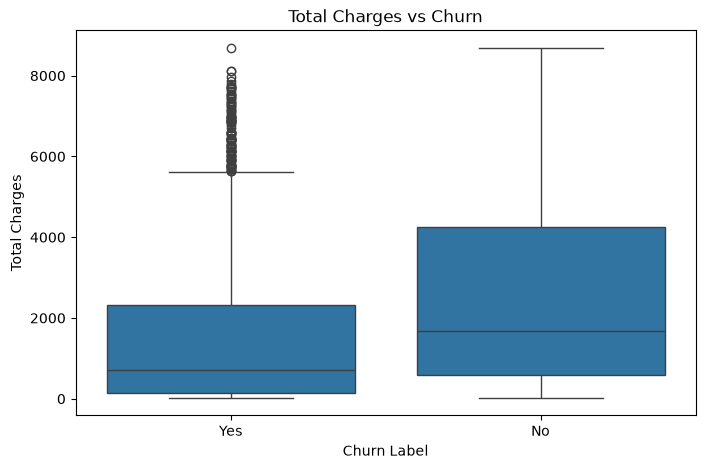

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=data
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")

plt.show()

In [41]:
data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


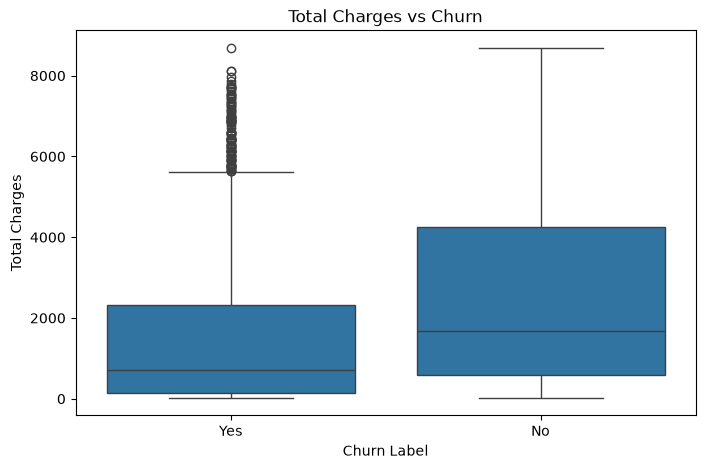

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=data
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")

plt.show()

In [43]:
data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


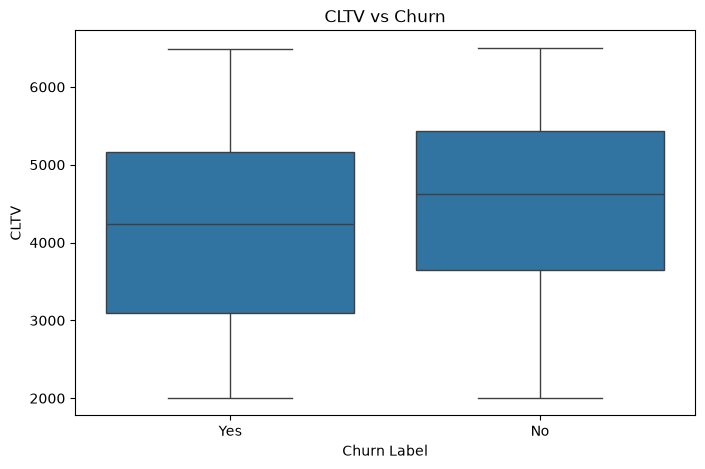

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="CLTV",
    data=data
)

plt.title("CLTV vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("CLTV")

plt.show()

In [45]:
data.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,4490.921337,4620.0,2003,6500
Yes,4149.414660,4238.0,2003,6484


In [46]:
data.groupby("Churn Label")[numerical_columns].mean()


,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,37.569965,61.265124,2555.344141,4490.921337
Yes,17.979133,74.441332,1531.796094,4149.414660


In [47]:
data.groupby("Churn Label")[numerical_columns].median()




,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,38.0,64.425,1683.60,4620.0
Yes,10.0,79.650,703.55,4238.0


In [48]:
data.groupby("Churn Label")[numerical_columns].mean()

,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,37.569965,61.265124,2555.344141,4490.921337
Yes,17.979133,74.441332,1531.796094,4149.414660


In [49]:
data.groupby("Churn Label")[numerical_columns].median()

,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,38.0,64.425,1683.60,4620.0
Yes,10.0,79.650,703.55,4238.0


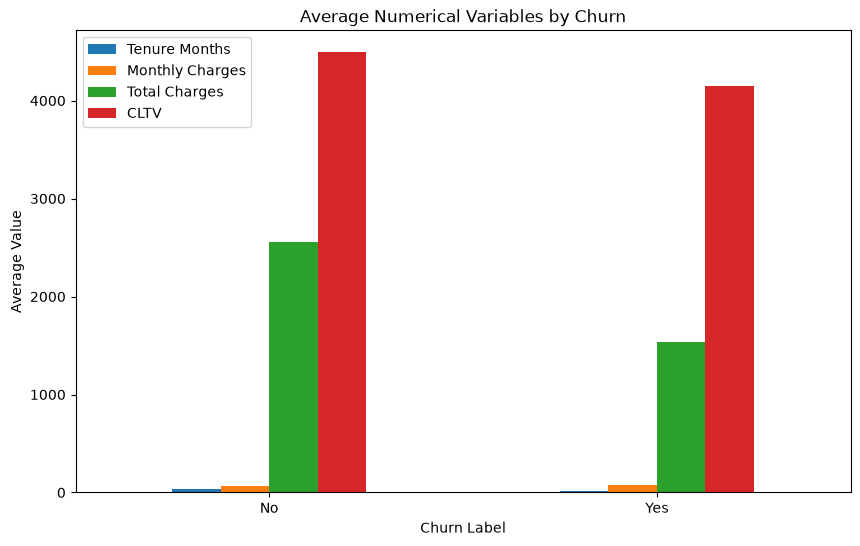

In [50]:
mean_values = data.groupby("Churn Label")[numerical_columns].mean()

mean_values.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Numerical Variables by Churn")
plt.xlabel("Churn Label")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

## Key Findings

### 1. Monthly Charges

Customers who churned had higher monthly charges than customers who stayed.
The average monthly charge for churned customers was 74.44, compared with
61.27 for customers who stayed. The median was also higher for churned
customers (79.65) compared with customers who stayed (64.43).

This suggests that higher monthly charges are associated with a higher
likelihood of churn. However, this analysis shows an association and does
not prove that higher charges directly cause customers to churn.

data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

In [51]:
data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


## Key Findings

### 1. Monthly Charges

Customers who churned had higher monthly charges than customers who stayed.
The average monthly charge for churned customers was 74.44, compared with
61.27 for customers who stayed. The median was also higher for churned
customers (79.65) compared with customers who stayed (64.43).

This suggests that higher monthly charges are associated with a higher
likelihood of churn. However, this analysis shows an association and does
not prove that higher charges directly cause customers to churn.


### 2. Tenure Months

Customers who churned had substantially shorter tenure than customers who
stayed. The average tenure of churned customers was 17.98 months, compared
with 37.57 months for customers who stayed. The median tenure was 10 months
for churned customers compared with 38 months for customers who stayed.

This suggests that newer customers are more likely to churn. Shorter tenure
is strongly associated with churn in this dataset.


### 3. Total Charges

[Write your finding based on your actual Total Charges results.]


### 4. CLTV

[Write your finding based on your actual CLTV results.]

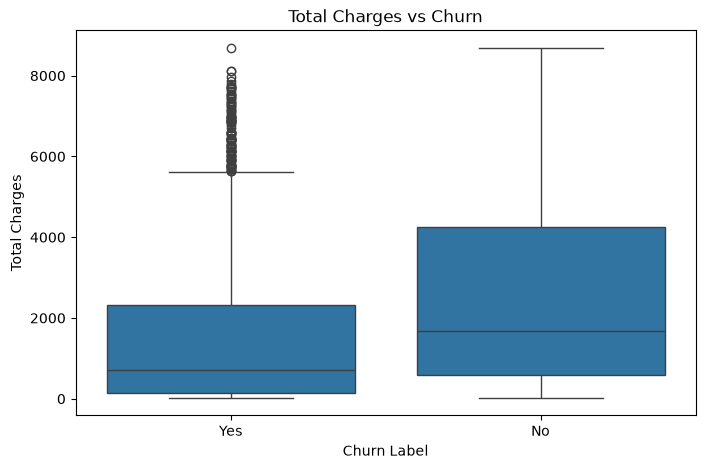

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="Total Charges",
    data=data
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("Total Charges")

plt.show()

In [53]:
data.groupby("Churn Label")["Total Charges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,2555.344141,1683.60,18.80,8672.45
Yes,1531.796094,703.55,18.85,8684.80


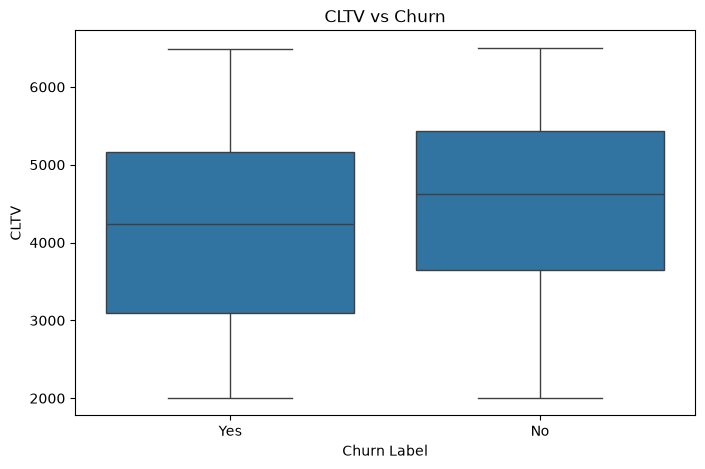

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn Label",
    y="CLTV",
    data=data
)

plt.title("CLTV vs Churn")
plt.xlabel("Churn Label")
plt.ylabel("CLTV")

plt.show()

In [55]:
data.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn Label,,,,
No,4490.921337,4620.0,2003,6500
Yes,4149.414660,4238.0,2003,6484


## Final Overall Findings

The numerical analysis shows several important differences between customers who stayed and customers who churned.

### 1. Monthly Charges

Customers who churned had higher monthly charges than customers who stayed. The average monthly charge was 74.44 for churned customers compared with 61.27 for customers who stayed.

This suggests that higher monthly charges are associated with a greater likelihood of churn.

### 2. Tenure Months

Customers who churned had considerably shorter tenure than customers who stayed. The average tenure was 17.98 months for churned customers compared with 37.57 months for customers who stayed.

The median tenure was 10 months for churned customers compared with 38 months for customers who stayed.

This suggests that newer customers are more likely to churn.

### 3. Total Charges

Total Charges were analyzed to compare the overall amount paid by customers who stayed and customers who churned.

The box plot and summary statistics can be used to identify differences between the two groups and understand whether Total Charges are associated with churn.

### 4. CLTV

CLTV was analyzed to compare the estimated customer lifetime value of customers who stayed and customers who churned.

The comparison helps identify whether customers with different lifetime values show different churn patterns.

### Overall Conclusion

Overall, the numerical analysis indicates that **shorter customer tenure and higher monthly charges are important numerical characteristics associated with churn** in this dataset.

These findings show associations rather than direct causes. Further analysis of categorical variables such as contract type, internet service, payment method, and support services can help explain why customers are more likely to churn.


# Customer Churn Prediction — Numerical Analysis

## Objective

The objective of this analysis is to study numerical variables in the customer churn dataset and identify patterns associated with customer churn.

The main numerical variables analyzed are:

* Tenure Months
* Monthly Charges
* Total Charges
* CLTV

The analysis uses summary statistics, histograms, box plots, and comparisons between customers who stayed and customers who churned.


# Customer Churn Prediction — Numerical Analysis

## 1. Import Libraries

## 2. Load the Dataset

## 3. Inspect the Dataset

## 4. Select Numerical Variables

## 5. Summary Statistics

## 6. Distribution of Numerical Variables

## 7. Outlier Analysis

## 8. Numerical Variables vs Churn

### 8.1 Monthly Charges vs Churn

### 8.2 Tenure Months vs Churn

### 8.3 Total Charges vs Churn

### 8.4 CLTV vs Churn

## 9. Key Findings

## 10. Final Overall Findings